# Kalshi API Explorer

This notebook explores the Kalshi prediction market API to understand:
- What market **categories/series** are available
- What individual **markets** exist within each category
- What **historical price data** (probability over time) is available
- Whether **sports markets** (e.g., NBA) exist

No API key required — all endpoints below are public.

**Base URL:** `https://api.elections.kalshi.com/trade-api/v2`

## 1. Setup & API Client

In [17]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import json
import time
from datetime import datetime, timezone

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)
sns.set_theme(style='whitegrid')

BASE_URL = "https://api.elections.kalshi.com/trade-api/v2"

def kalshi_get(endpoint, params=None):
    """Generic GET request to Kalshi API with basic error handling."""
    url = f"{BASE_URL}/{endpoint.lstrip('/')}"
    response = requests.get(url, params=params, timeout=10)
    if response.status_code == 200:
        return response.json()
    else:
        print(f"  Error {response.status_code}: {response.text[:200]}")
        return None

print("Setup complete.")

Setup complete.


## 2. Browse Available Series (Top-level Categories)

A **Series** is a recurring market type (e.g., 'Will the Fed raise rates in March?'). 
This is the top-level way to browse categories on Kalshi.

In [18]:
# Pull all series — paginate if needed
all_series = []
cursor = None

for _ in range(10):  # max 10 pages
    params = {"limit": 200}
    if cursor:
        params["cursor"] = cursor
    data = kalshi_get("/series", params=params)
    if not data or not data.get("series"):
        break
    all_series.extend(data["series"])
    cursor = data.get("cursor")
    if not cursor:
        break
    time.sleep(0.2)

print(f"Total series found: {len(all_series)}")
if all_series:
    print("\nSample raw keys:", list(all_series[0].keys()))

Total series found: 8448

Sample raw keys: ['additional_prohibitions', 'category', 'contract_terms_url', 'contract_url', 'fee_multiplier', 'fee_type', 'frequency', 'settlement_sources', 'tags', 'ticker', 'title']


In [19]:
# Build a clean DataFrame of series
if all_series:
    series_df = pd.DataFrame(all_series)
    # Show whichever columns are actually present
    useful_cols = [c for c in ['ticker', 'title', 'category', 'tags', 'frequency', 'status'] if c in series_df.columns]
    print(series_df[useful_cols].to_string(index=False))
else:
    print("No series data returned — check endpoint or API availability.")

                                 ticker                                                                                                                                      title               category                                                      tags   frequency
                     KXNEWCOACHCHIBEARS                                                                                                                    Chicago Bears new coach                 Sports                                                [Football]      custom
                       KXDUTCHCOALITION                                                                                                            parties in next dutch coalition               Politics                        [Foreign Elections, International]     one_off
                              PRESNOM-R                                                                                                                  Republican Primary winner      

Series count by category:
category
Politics                  2435
Entertainment             2113
Sports                    1305
Elections                  431
Economics                  390
Companies                  285
Mentions                   258
Climate and Weather        249
Crypto                     207
Science and Technology     182
Financials                 174
World                      151
Health                     111
Social                      72
                            43
Transportation              40
Education                    2


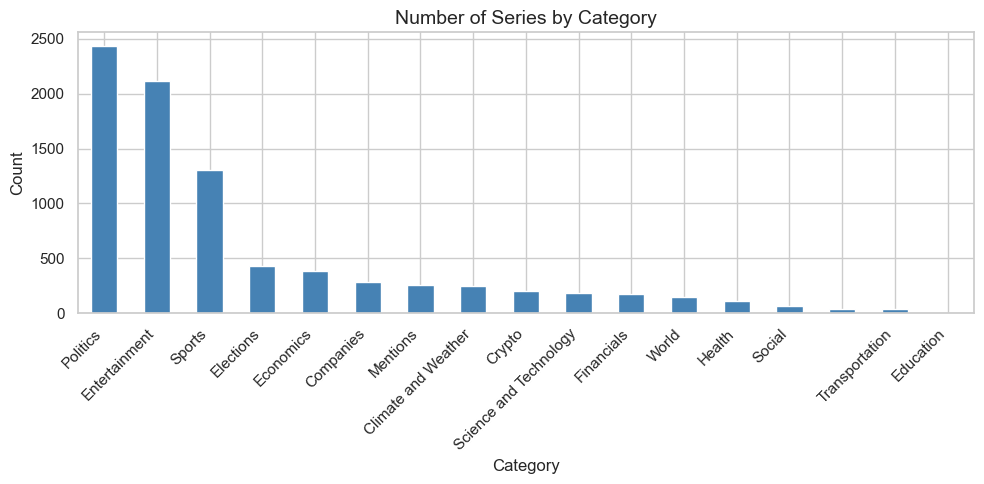

In [20]:
# Count series by category (if category field exists)
if all_series and 'category' in series_df.columns:
    cat_counts = series_df['category'].value_counts()
    print("Series count by category:")
    print(cat_counts.to_string())

    fig, ax = plt.subplots(figsize=(10, 5))
    cat_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title('Number of Series by Category', fontsize=14)
    ax.set_xlabel('Category')
    ax.set_ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
elif all_series and 'tags' in series_df.columns:
    # Fallback: use tags if category not present
    from collections import Counter
    all_tags = [tag for tags in series_df['tags'].dropna() for tag in (tags if isinstance(tags, list) else [])]
    tag_counts = pd.Series(Counter(all_tags)).sort_values(ascending=False).head(20)
    print("Top 20 tags across all series:")
    print(tag_counts.to_string())

## 3. Browse Open Markets

Let's pull **currently open markets** and see what's available — this shows us what topics Kalshi is running right now.

In [21]:
# Pull open markets (paginate)
all_markets = []
cursor = None

for page in range(15):  # up to 15 pages of 200 = 3000 markets
    params = {"limit": 200, "status": "open"}
    if cursor:
        params["cursor"] = cursor
    data = kalshi_get("/markets", params=params)
    if not data or not data.get("markets"):
        break
    all_markets.extend(data["markets"])
    cursor = data.get("cursor")
    if not cursor:
        break
    time.sleep(0.3)

print(f"Total open markets found: {len(all_markets)}")
if all_markets:
    print("\nAvailable fields per market:", list(all_markets[0].keys()))

Total open markets found: 3000

Available fields per market: ['can_close_early', 'close_time', 'created_time', 'custom_strike', 'event_ticker', 'expected_expiration_time', 'expiration_time', 'expiration_value', 'is_provisional', 'last_price', 'last_price_dollars', 'latest_expiration_time', 'liquidity', 'liquidity_dollars', 'market_type', 'mve_collection_ticker', 'mve_selected_legs', 'no_ask', 'no_ask_dollars', 'no_bid', 'no_bid_dollars', 'no_sub_title', 'notional_value', 'notional_value_dollars', 'open_interest', 'open_interest_fp', 'open_time', 'previous_price', 'previous_price_dollars', 'previous_yes_ask', 'previous_yes_ask_dollars', 'previous_yes_bid', 'previous_yes_bid_dollars', 'price_level_structure', 'price_ranges', 'response_price_units', 'result', 'rules_primary', 'rules_secondary', 'settlement_timer_seconds', 'status', 'strike_type', 'subtitle', 'tick_size', 'ticker', 'title', 'updated_time', 'volume', 'volume_24h', 'volume_24h_fp', 'volume_fp', 'yes_ask', 'yes_ask_dollars', 

In [22]:
# Build clean markets DataFrame
if all_markets:
    markets_df = pd.DataFrame(all_markets)
    
    # Core columns we care about
    core_cols = [c for c in [
        'ticker', 'title', 'category', 'series_ticker', 'event_ticker',
        'yes_bid', 'yes_ask', 'last_price', 'volume', 'open_interest',
        'close_time', 'status'
    ] if c in markets_df.columns]

    print(f"Columns available: {list(markets_df.columns)}")
    print(f"\nSample of markets:")
    print(markets_df[core_cols].head(20).to_string(index=False))

Columns available: ['can_close_early', 'close_time', 'created_time', 'custom_strike', 'event_ticker', 'expected_expiration_time', 'expiration_time', 'expiration_value', 'is_provisional', 'last_price', 'last_price_dollars', 'latest_expiration_time', 'liquidity', 'liquidity_dollars', 'market_type', 'mve_collection_ticker', 'mve_selected_legs', 'no_ask', 'no_ask_dollars', 'no_bid', 'no_bid_dollars', 'no_sub_title', 'notional_value', 'notional_value_dollars', 'open_interest', 'open_interest_fp', 'open_time', 'previous_price', 'previous_price_dollars', 'previous_yes_ask', 'previous_yes_ask_dollars', 'previous_yes_bid', 'previous_yes_bid_dollars', 'price_level_structure', 'price_ranges', 'response_price_units', 'result', 'rules_primary', 'rules_secondary', 'settlement_timer_seconds', 'status', 'strike_type', 'subtitle', 'tick_size', 'ticker', 'title', 'updated_time', 'volume', 'volume_24h', 'volume_24h_fp', 'volume_fp', 'yes_ask', 'yes_ask_dollars', 'yes_bid', 'yes_bid_dollars', 'yes_sub_tit

In [23]:
# Check for sports / NBA markets by searching titles
if all_markets:
    sports_keywords = ['nba', 'nfl', 'nhl', 'mlb', 'soccer', 'sport', 'game', 'championship',
                       'basketball', 'football', 'baseball', 'hockey', 'tennis', 'golf']
    
    title_col = 'title' if 'title' in markets_df.columns else 'subtitle'
    if title_col in markets_df.columns:
        mask = markets_df[title_col].str.lower().str.contains('|'.join(sports_keywords), na=False)
        sports_markets = markets_df[mask]
        print(f"Sports-related open markets: {len(sports_markets)}")
        if not sports_markets.empty:
            show_cols = [c for c in [title_col, 'ticker', 'last_price', 'volume'] if c in sports_markets.columns]
            print(sports_markets[show_cols].to_string(index=False))
        else:
            print("No sports markets found in current open markets.")
    
    # Also check category column
    if 'category' in markets_df.columns:
        print("\nAll categories present:")
        print(markets_df['category'].value_counts().to_string())

Sports-related open markets: 0
No sports markets found in current open markets.


## 4. Pull Historical Markets (Resolved/Closed)

For building a simulator, **resolved markets are the gold mine** — they show the full probability path from open to close. Let's pull some.

In [ ]:
# Pull settled markets (fully resolved — these have complete probability paths)
resolved_markets = []
cursor = None

for _ in range(10):
    params = {"limit": 200, "status": "settled"}
    if cursor:
        params["cursor"] = cursor
    data = kalshi_get("/markets", params=params)
    if not data or not data.get("markets"):
        break
    resolved_markets.extend(data["markets"])
    cursor = data.get("cursor")
    if not cursor:
        break
    time.sleep(0.3)

print(f"Total settled markets found: {len(resolved_markets)}")
if resolved_markets:
    resolved_df = pd.DataFrame(resolved_markets)
    print("\nSample settled markets:")
    show_cols = [c for c in ['ticker', 'title', 'result', 'last_price', 'volume'] if c in resolved_df.columns]
    print(resolved_df[show_cols].head(20).to_string(index=False))

## 5. Drill Into a Single Market — Price History

Now let's pick one market and pull its **full price history** — this gives us the probability over time, which is the core data for our simulator.

In [25]:
def get_market_history(ticker, period_interval=60):
    """
    Pull OHLC candlestick history for a market.
    period_interval: candle size in minutes (1, 60, or 1440)
    Returns a DataFrame with timestamp and price columns.
    """
    data = kalshi_get(f"/markets/{ticker}/history", params={"period_interval": period_interval})
    if not data:
        return None
    
    history = data.get("history", [])
    if not history:
        print(f"No history data for {ticker}")
        return None
    
    df = pd.DataFrame(history)
    
    # Convert timestamp
    if 'ts' in df.columns:
        df['datetime'] = pd.to_datetime(df['ts'], unit='s', utc=True)
    elif 'end_period_ts' in df.columns:
        df['datetime'] = pd.to_datetime(df['end_period_ts'], unit='s', utc=True)
    
    # Normalize prices: Kalshi prices are in cents (0-100)
    price_cols = [c for c in ['yes_price', 'price', 'open', 'close', 'high', 'low'] if c in df.columns]
    for col in price_cols:
        if df[col].max() > 1:
            df[f'{col}_pct'] = df[col]  # already in cents/percent
    
    print(f"History for {ticker}: {len(df)} candles, columns: {list(df.columns)}")
    return df

def get_market_trades(ticker, limit=1000):
    """
    Pull individual trade records for a market.
    Returns a DataFrame with trade timestamps and prices.
    """
    all_trades = []
    cursor = None
    
    for _ in range(10):
        params = {"limit": min(limit, 1000), "ticker": ticker}
        if cursor:
            params["cursor"] = cursor
        data = kalshi_get("/markets/trades", params=params)
        if not data or not data.get("trades"):
            break
        all_trades.extend(data["trades"])
        cursor = data.get("cursor")
        if not cursor or len(all_trades) >= limit:
            break
        time.sleep(0.2)
    
    if not all_trades:
        print(f"No trade data for {ticker}")
        return None
    
    df = pd.DataFrame(all_trades)
    if 'created_time' in df.columns:
        df['datetime'] = pd.to_datetime(df['created_time'])
    
    print(f"Trades for {ticker}: {len(df)} trades, columns: {list(df.columns)}")
    return df

print("Functions defined.")

Functions defined.


In [26]:
# Pick the most liquid open market to test history endpoints
if all_markets and 'volume' in markets_df.columns:
    top_markets = markets_df.nlargest(10, 'volume')[['ticker', 'title', 'volume', 'last_price']]
    print("Top 10 markets by volume:")
    print(top_markets.to_string(index=False))
    
    sample_ticker = top_markets.iloc[0]['ticker']
    print(f"\nWill pull history for: {sample_ticker}")
elif all_markets:
    sample_ticker = markets_df.iloc[0]['ticker']
    print(f"Using first available market: {sample_ticker}")

Top 10 markets by volume:
                                                   ticker                                                                                                                                                                                                                                                                                                                                                                                          title  volume  last_price
KXMVESPORTSMULTIGAMEEXTENDED-S20267C346104403-476544C1DFC                                                  yes Phoenix,yes Houston,yes San Antonio,yes Boston,yes Denver,yes Orlando,yes New York,yes Minnesota,yes San Antonio,yes Cleveland,yes Over 213.5 points scored,yes Over 222.5 points scored,yes Over 223.5 points scored,yes Over 221.5 points scored,yes Over 220.5 points scored,yes Over 223.5 points scored,yes Over 216.5 points scored   22727           0
KXMVESPORTSMULTIGAMEEXTENDED-S20260A6FD9702F2-F72079

In [27]:
# Pull hourly price history for the sample market
if 'sample_ticker' in dir():
    hist_df = get_market_history(sample_ticker, period_interval=60)
    if hist_df is not None:
        print("\nSample rows:")
        print(hist_df.head(10).to_string(index=False))

  Error 404: 404 page not found


In [28]:
# Pull individual trades for the sample market
if 'sample_ticker' in dir():
    trades_df = get_market_trades(sample_ticker, limit=500)
    if trades_df is not None:
        print("\nSample rows:")
        print(trades_df.head(10).to_string(index=False))

Trades for KXMVESPORTSMULTIGAMEEXTENDED-S20267C346104403-476544C1DFC: 1 trades, columns: ['count', 'count_fp', 'created_time', 'no_price', 'no_price_dollars', 'price', 'taker_side', 'ticker', 'trade_id', 'yes_price', 'yes_price_dollars', 'datetime']

Sample rows:
 count count_fp                created_time  no_price no_price_dollars  price taker_side                                                    ticker                             trade_id  yes_price yes_price_dollars                         datetime
 22727 22727.00 2026-02-11T00:47:35.199057Z        99           0.9980      0        yes KXMVESPORTSMULTIGAMEEXTENDED-S20267C346104403-476544C1DFC bd5637f7-1609-5456-a069-f653f87b9e9a          0            0.0020 2026-02-11 00:47:35.199057+00:00


## 6. Visualize Probability Path for a Single Market

Plot how the **yes-probability changed over the life of the market** — this is exactly what our simulator will replicate.

In [29]:
def plot_probability_path(hist_df, ticker, trades_df=None):
    """
    Plot the probability (yes price) over the life of a market.
    Overlays individual trades if provided.
    """
    if hist_df is None or 'datetime' not in hist_df.columns:
        print("No data to plot.")
        return

    # Identify the price column
    price_col = next((c for c in ['yes_price', 'close', 'price'] if c in hist_df.columns), None)
    if price_col is None:
        print(f"No recognized price column. Available: {list(hist_df.columns)}")
        return

    fig, ax = plt.subplots(figsize=(12, 5))

    # Main probability line
    ax.plot(hist_df['datetime'], hist_df[price_col], 
            color='steelblue', linewidth=2, label='Yes price (¢)')
    ax.fill_between(hist_df['datetime'], hist_df[price_col], 
                    alpha=0.15, color='steelblue')

    # Overlay individual trades if available
    if trades_df is not None and 'datetime' in trades_df.columns:
        trade_price_col = next((c for c in ['yes_price', 'price'] if c in trades_df.columns), None)
        if trade_price_col:
            ax.scatter(trades_df['datetime'], trades_df[trade_price_col],
                      alpha=0.3, s=10, color='orange', label='Trades', zorder=5)

    ax.axhline(50, linestyle='--', color='gray', alpha=0.6, label='50% line')
    ax.set_ylim(0, 100)
    ax.set_ylabel('Yes Price (¢ = % probability)', fontsize=12)
    ax.set_xlabel('Date/Time', fontsize=12)
    ax.set_title(f'Probability Path: {ticker}', fontsize=14)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d %H:%M'))
    plt.xticks(rotation=45, ha='right')
    ax.legend()
    plt.tight_layout()
    plt.show()

# Plot it
if 'hist_df' in dir() and hist_df is not None:
    plot_probability_path(hist_df, sample_ticker, 
                          trades_df=trades_df if 'trades_df' in dir() else None)
else:
    print("Run cells above to fetch data first.")

Run cells above to fetch data first.


## 7. Compare Multiple Markets Side-by-Side

To build a simulator, we need many historical probability paths. Let's pull several resolved markets and compare their trajectories.

In [30]:
def fetch_multiple_histories(tickers, period_interval=60):
    """
    Fetch history for a list of market tickers.
    Returns a dict of {ticker: DataFrame}.
    """
    histories = {}
    for ticker in tickers:
        print(f"  Fetching {ticker}...", end=' ')
        df = get_market_history(ticker, period_interval)
        if df is not None:
            histories[ticker] = df
        time.sleep(0.3)
    return histories

# Pick top resolved markets by volume (if available)
if resolved_markets and 'volume' in resolved_df.columns:
    top_resolved = resolved_df.nlargest(10, 'volume')['ticker'].tolist()
elif resolved_markets:
    top_resolved = resolved_df['ticker'].head(10).tolist()
else:
    top_resolved = []

print(f"Fetching history for {len(top_resolved)} resolved markets...")
if top_resolved:
    histories = fetch_multiple_histories(top_resolved[:5], period_interval=60)  # start with 5
    print(f"\nSuccessfully fetched: {list(histories.keys())}")

Fetching history for 0 resolved markets...


In [31]:
def plot_multiple_paths(histories, title="Probability Paths — Resolved Markets"):
    """
    Plot overlapping probability paths for multiple resolved markets,
    normalized to [0, 1] time axis so they're comparable.
    """
    if not histories:
        print("No histories to plot.")
        return

    fig, ax = plt.subplots(figsize=(12, 6))
    colors = plt.cm.tab10.colors

    price_candidates = ['yes_price', 'close', 'price']

    for i, (ticker, df) in enumerate(histories.items()):
        if 'datetime' not in df.columns:
            continue
        price_col = next((c for c in price_candidates if c in df.columns), None)
        if price_col is None:
            continue
        
        df = df.sort_values('datetime').dropna(subset=[price_col])
        if len(df) < 2:
            continue
        
        # Normalize time axis to [0, 100]% of market life
        t_start = df['datetime'].min()
        t_end = df['datetime'].max()
        duration = (t_end - t_start).total_seconds()
        if duration == 0:
            continue
        df = df.copy()
        df['time_pct'] = (df['datetime'] - t_start).dt.total_seconds() / duration * 100
        
        ax.plot(df['time_pct'], df[price_col], 
                color=colors[i % 10], linewidth=1.5, alpha=0.8, label=ticker)

    ax.axhline(50, linestyle='--', color='gray', alpha=0.5, label='50% line')
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.set_xlabel('% of Market Lifetime Elapsed', fontsize=12)
    ax.set_ylabel('Yes Price (¢ = % probability)', fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.show()

if 'histories' in dir():
    plot_multiple_paths(histories)

## 8. Summary — What Data Is Available?

Let's print a clean summary of everything we found.

In [32]:
print("=" * 60)
print("KALSHI API EXPLORATION SUMMARY")
print("=" * 60)

print(f"\n Total series/categories found: {len(all_series)}")
if all_series and 'category' in series_df.columns:
    print(f"   Categories: {series_df['category'].unique().tolist()}")

print(f"\n Total open markets found: {len(all_markets)}")
if all_markets and 'category' in markets_df.columns:
    print(f"   Categories: {markets_df['category'].value_counts().to_dict()}")

print(f"\n Total resolved markets found: {len(resolved_markets)}")

if 'histories' in dir():
    print(f"\n Price history successfully pulled for: {len(histories)} markets")
    for ticker, df in histories.items():
        price_col = next((c for c in ['yes_price', 'close', 'price'] if c in df.columns), 'N/A')
        print(f"   {ticker}: {len(df)} candles, price column = '{price_col}'")

print("\n" + "=" * 60)
print("NEXT STEPS: Use the findings above to decide which")
print("market category to build the simulator around.")
print("=" * 60)

KALSHI API EXPLORATION SUMMARY

 Total series/categories found: 8448
   Categories: ['Sports', 'Politics', 'Economics', 'Entertainment', 'Mentions', 'Climate and Weather', 'Elections', 'Social', 'Science and Technology', 'Financials', '', 'World', 'Companies', 'Crypto', 'Health', 'Transportation', 'Education']

 Total open markets found: 3000

 Total resolved markets found: 0

NEXT STEPS: Use the findings above to decide which
market category to build the simulator around.


## 9. FIXES — Find Simple NBA Markets & Working History Endpoints

In [40]:
# FIX 1: Find the correct status filter for settled/closed markets
print("Testing valid status filter values...")
for status_val in ["settled", "closed", "finalized", "inactive", "all"]:
    data = kalshi_get("/markets", params={"limit": 5, "status": status_val})
    if data and data.get("markets"):
        count = len(data["markets"])
        sample = data["markets"][0].get("ticker", "?")
        print(f"  status='{status_val}' -> {count} markets returned (e.g. {sample})")
    else:
        print(f"  status='{status_val}' -> FAILED or empty")

Testing valid status filter values...
  status='settled' -> 5 markets returned (e.g. KXTABLETENNIS-26FEB101845DWRSWN-SWN)
  status='closed' -> 5 markets returned (e.g. KXXRPD-26FEB1020-T2.0399)
  Error 400: {"error":{"code":"bad_request","message":"bad request","details":"invalid status filter"}}
  status='finalized' -> FAILED or empty
  Error 400: {"error":{"code":"bad_request","message":"bad request","details":"invalid status filter"}}
  status='inactive' -> FAILED or empty
  Error 400: {"error":{"code":"bad_request","message":"bad request","details":"invalid status filter"}}
  status='all' -> FAILED or empty


In [41]:
# FIX 2: Find simple NBA single-game markets (not multi-leg parlays)
# The top-volume markets are multi-leg "KXMVESPORTSMULTIGAMEEXTENDED" 
# We want simpler markets like KXNBA* or individual game lines

nba_series = []
nba_markets_simple = []

# Search series for NBA
if all_series:
    nba_series = [s for s in all_series 
                  if 'nba' in s.get('ticker', '').lower() 
                  or 'nba' in s.get('title', '').lower()]
    print(f"NBA series found: {len(nba_series)}")
    for s in nba_series[:10]:
        print(f"  Ticker: {s['ticker']:<40} Title: {s['title'][:60]}")

# Filter open markets for simpler NBA tickers (not multi-leg extended)
if all_markets:
    # Exclude the complex multi-leg markets, find single-event NBA markets
    for m in all_markets:
        ticker = m.get('ticker', '')
        title = m.get('title', '') or ''
        subtitle = m.get('subtitle', '') or ''
        event = m.get('event_ticker', '') or ''
        
        is_nba = ('NBA' in ticker.upper() or 'NBA' in title.upper() 
                  or 'NBA' in subtitle.upper() or 'NBA' in event.upper())
        is_simple = 'MULTIGAME' not in ticker.upper()
        
        if is_nba and is_simple:
            nba_markets_simple.append(m)

    print(f"\nSimple (non-parlay) NBA markets: {len(nba_markets_simple)}")
    if nba_markets_simple:
        nba_df = pd.DataFrame(nba_markets_simple)
        show = [c for c in ['ticker', 'title', 'subtitle', 'event_ticker', 'last_price', 'volume'] 
                if c in nba_df.columns]
        print(nba_df[show].head(20).to_string(index=False))

NBA series found: 158
  Ticker: KXFIRSTPICKNBA                           Title: NBA first pick
  Ticker: KXNBAGAME                                Title: Professional Basketball Game
  Ticker: KXNBADRAFT3                              Title: NBA Draft Third Pick
  Ticker: KXNBADRAFTTOP30                          Title: NBA Draft Top 30 Pick
  Ticker: KXNBAWINS                                Title: Pro basketball wins
  Ticker: KXCITYNBAEXPAND                          Title: Cities NBA expand
  Ticker: KXNBA3PT                                 Title: Pro Basketball Player Threes
  Ticker: KXNBAALLSTARMVP                          Title: NBA All-Star Game MVP
  Ticker: KXNBA1HSPREAD                            Title: Pro Basketball 1st Half Spread
  Ticker: KXNBA2D                                  Title: Pro Basketball Double Double

Simple (non-parlay) NBA markets: 0


In [42]:
# FIX 3: Try ALL sports-category series to find NBA event tickers
# Then use an event ticker to pull its markets directly

sports_series = [s for s in all_series if s.get('category') == 'Sports']
print(f"Total Sports series: {len(sports_series)}")

# Show a sample of sports series tickers to understand naming conventions
print("\nSample Sports series tickers:")
for s in sports_series[:30]:
    print(f"  {s['ticker']:<50}  {s['title'][:55]}")

Total Sports series: 1305

Sample Sports series tickers:
  KXLEADERMLBWINS                                     MLB Wins Leader
  KXMVEGRAMMYS                                        MVE NFL Grammys
  KXNFLWINS-LV                                        Pro football wins Las Vegas
  KXCRYPTOFIGHTNIGHT                                  Crypto Fight Night
  KXRECORDNFLWORST                                    worst football record
  KXSTARTINGQBWEEK1                                   NFL Starting QB Week 1
  KXNFLSBMVPDEF                                       Defensive Player Championship MVP
  KXTTELITEGAME                                       TT Elite Series Table Tennis Game
  KXGENESISINVITATIONAL                               Genesis Invitational Winner?
  KXNBLGAME                                           NBL Basketball Game
  KXNEWCOACHNE                                        New England Patriots new coach
  KXPGASOLHEIM                                        Solheim Cup
  KXUFAWEST

In [43]:
# Pull NBA markets directly using the NBA series tickers we found
# This is more reliable than filtering the general open markets list

key_nba_series = [
    "KXNBAGAME",        # Will [Team] win? — the core game market
    "KXNBA1HSPREAD",    # 1st half spread
    "KXNBA3PT",         # Player 3-pointers
    "KXNBA2D",          # Double doubles
    "KXNBAWINS",        # Season win totals
]

all_nba_markets = []

for series_ticker in key_nba_series:
    data = kalshi_get("/markets", params={
        "series_ticker": series_ticker, 
        "limit": 100,
        "status": "open"
    })
    markets = data.get("markets", []) if data else []
    for m in markets:
        m["series"] = series_ticker   # tag which series it came from
    all_nba_markets.extend(markets)
    print(f"  {series_ticker:<25} -> {len(markets)} open markets")

print(f"\nTotal NBA markets found: {len(all_nba_markets)}")

if all_nba_markets:
    nba_df = pd.DataFrame(all_nba_markets)
    show = [c for c in ['series', 'ticker', 'title', 'subtitle', 'last_price', 'volume', 'close_time']
            if c in nba_df.columns]
    print(nba_df[show].to_string(index=False))
    
    # Pick best market for history test
    if 'volume' in nba_df.columns and nba_df['volume'].sum() > 0:
        sports_ticker = nba_df.nlargest(1, 'volume').iloc[0]['ticker']
    else:
        sports_ticker = nba_df.iloc[0]['ticker']
    print(f"\nBest market to test history on: {sports_ticker}")

  KXNBAGAME                 -> 42 open markets
  KXNBA1HSPREAD             -> 43 open markets
  KXNBA3PT                  -> 90 open markets
  KXNBA2D                   -> 25 open markets
  KXNBAWINS                 -> 100 open markets

Total NBA markets found: 300
       series                                   ticker                                                                      title subtitle  last_price  volume           close_time
    KXNBAGAME              KXNBAGAME-26FEB12DALLAL-LAL                                            Dallas at Los Angeles L Winner?                   75     683 2026-02-27T03:00:00Z
    KXNBAGAME              KXNBAGAME-26FEB12DALLAL-DAL                                            Dallas at Los Angeles L Winner?                   29     745 2026-02-27T03:00:00Z
    KXNBAGAME              KXNBAGAME-26FEB12PORUTA-UTA                                                   Portland at Utah Winner?                   41     457 2026-02-27T02:00:00Z
    KXNBAGAME 

In [44]:
# History/candlestick endpoints require authentication — not available publicly.
# Our strategy: use the TRADES endpoint instead (already confirmed working).
# Trades give us tick-level price data, which is more granular than OHLC anyway.

# Set the test ticker to the best NBA game market from Cell 9.4
if 'all_nba_markets' in dir() and all_nba_markets:
    nba_df_temp = pd.DataFrame(all_nba_markets)
    if 'volume' in nba_df_temp.columns and nba_df_temp['volume'].sum() > 0:
        sports_ticker = nba_df_temp.nlargest(1, 'volume').iloc[0]['ticker']
        title = nba_df_temp.nlargest(1, 'volume').iloc[0].get('title', '')
    else:
        sports_ticker = nba_df_temp.iloc[0]['ticker']
        title = nba_df_temp.iloc[0].get('title', '')
    print(f"Using NBA market: {sports_ticker}")
    print(f"Title: {title}")
else:
    # Fallback: use the top-volume market from the general list
    sports_ticker = markets_df.nlargest(1, 'volume').iloc[0]['ticker']
    print(f"NBA markets not found — using fallback: {sports_ticker}")

print("\nSkipping history endpoint (requires auth). Moving to trades-based history.")

Using NBA market: KXNBAGAME-26FEB10INDNYK-NYK
Title: Indiana at New York Winner?

Skipping history endpoint (requires auth). Moving to trades-based history.


In [45]:
# FIX 6: Build price history FROM TRADES (works regardless of history endpoint)
# Since /trades already works, we can reconstruct the full probability path
# from individual trade records — this is actually more granular than OHLC

def build_price_history_from_trades(ticker, limit=5000):
    """
    Reconstruct the probability path for a market using its trade feed.
    Each trade has a yes_price — plotting these over time gives us the
    probability evolution that our simulator will learn from.
    """
    all_trades = []
    cursor = None
    
    for _ in range(20):
        params = {"limit": 1000, "ticker": ticker}
        if cursor:
            params["cursor"] = cursor
        data = kalshi_get("/markets/trades", params=params)
        if not data or not data.get("trades"):
            break
        all_trades.extend(data["trades"])
        cursor = data.get("cursor")
        if not cursor or len(all_trades) >= limit:
            break
        time.sleep(0.2)
    
    if not all_trades:
        return None
    
    df = pd.DataFrame(all_trades)
    df['datetime'] = pd.to_datetime(df['created_time'])
    df = df.sort_values('datetime').reset_index(drop=True)
    
    # yes_price is in cents (0-100), divide by 100 for probability (0-1)
    if 'yes_price' in df.columns:
        df['probability'] = df['yes_price'] / 100
    
    print(f"{ticker}: {len(df)} trades | "
          f"from {df['datetime'].min().strftime('%Y-%m-%d %H:%M')} "
          f"to {df['datetime'].max().strftime('%Y-%m-%d %H:%M')}")
    return df

# Test with the best sports market we found
test_ticker = sports_ticker if 'sports_ticker' in dir() else sample_ticker
print(f"Building trade-based price history for: {test_ticker}")
trade_history = build_price_history_from_trades(test_ticker, limit=2000)

if trade_history is not None:
    print(f"\nColumns: {list(trade_history.columns)}")
    print(trade_history[['datetime', 'yes_price', 'probability', 'count']].head(10).to_string(index=False))

Building trade-based price history for: KXNBAGAME-26FEB10INDNYK-NYK
KXNBAGAME-26FEB10INDNYK-NYK: 2000 trades | from 2026-02-11 00:29 to 2026-02-11 01:09

Columns: ['count', 'count_fp', 'created_time', 'no_price', 'no_price_dollars', 'price', 'taker_side', 'ticker', 'trade_id', 'yes_price', 'yes_price_dollars', 'datetime', 'probability']
                        datetime  yes_price  probability  count
2026-02-11 00:29:32.076973+00:00         83         0.83     14
2026-02-11 00:29:34.446146+00:00         83         0.83      1
2026-02-11 00:29:34.538100+00:00         83         0.83      2
2026-02-11 00:29:35.054506+00:00         83         0.83     54
2026-02-11 00:29:40.822279+00:00         83         0.83      6
2026-02-11 00:29:48.140144+00:00         83         0.83      1
2026-02-11 00:29:49.300494+00:00         83         0.83     59
2026-02-11 00:29:50.396058+00:00         83         0.83     23
2026-02-11 00:29:53.226215+00:00         83         0.83    235
2026-02-11 00:29:54.7

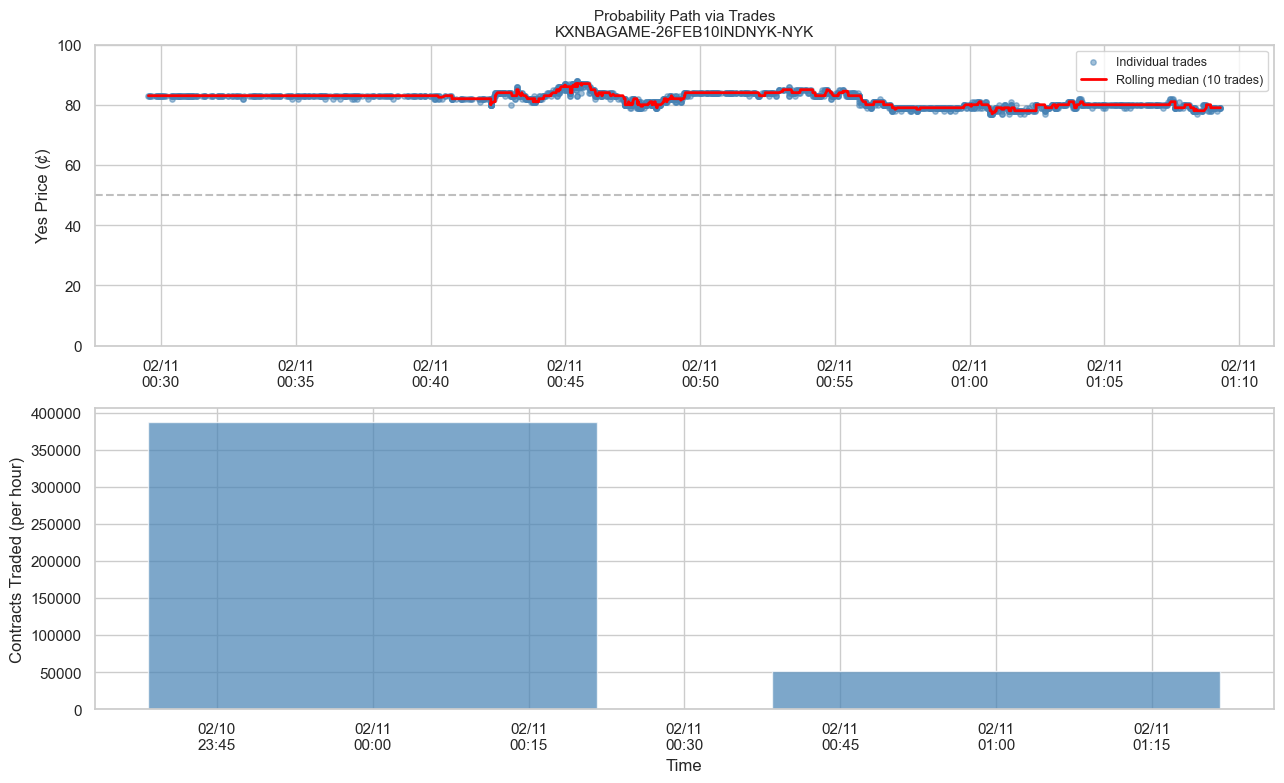


Total trades: 2000
Price range: 77¢ — 88¢
Final price: 79¢  (79% implied probability)


In [46]:
# FIX 7: Plot the trade-based probability path
if trade_history is not None and 'probability' in trade_history.columns:
    fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=False)
    
    # Top: raw trade prices over time
    ax1 = axes[0]
    ax1.scatter(trade_history['datetime'], trade_history['yes_price'],
                alpha=0.5, s=15, color='steelblue', label='Individual trades')
    
    # Rolling median to smooth the path
    if len(trade_history) > 10:
        trade_history['smoothed'] = trade_history['yes_price'].rolling(10, min_periods=1).median()
        ax1.plot(trade_history['datetime'], trade_history['smoothed'],
                 color='red', linewidth=2, label='Rolling median (10 trades)')
    
    ax1.axhline(50, linestyle='--', color='gray', alpha=0.5)
    ax1.set_ylim(0, 100)
    ax1.set_ylabel('Yes Price (¢)')
    ax1.set_title(f'Probability Path via Trades\n{test_ticker[:70]}', fontsize=11)
    ax1.legend(fontsize=9)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d\n%H:%M'))
    
    # Bottom: trade volume over time (bar chart bucketed by hour)
    ax2 = axes[1]
    if 'count' in trade_history.columns:
        trade_history['hour'] = trade_history['datetime'].dt.floor('h')
        vol_by_hour = trade_history.groupby('hour')['count'].sum()
        ax2.bar(vol_by_hour.index, vol_by_hour.values, width=0.03, 
                color='steelblue', alpha=0.7)
        ax2.set_ylabel('Contracts Traded (per hour)')
        ax2.set_xlabel('Time')
        ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d\n%H:%M'))
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nTotal trades: {len(trade_history)}")
    print(f"Price range: {trade_history['yes_price'].min()}¢ — {trade_history['yes_price'].max()}¢")
    print(f"Final price: {trade_history['yes_price'].iloc[-1]}¢  ({trade_history['yes_price'].iloc[-1]}% implied probability)")
else:
    print("No trade history to plot — check cells above.")